In [ ]:
import sys
import os

# Détection automatique de la racine du projet
# On remonte d'un niveau depuis le dossier 'notebooks'
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Ajout au path pour pouvoir faire "from src..."
if project_root not in sys.path:
    sys.path.append(project_root)

# Définition des chemins absolus
DATA_RAW = os.path.join(project_root, "data", "raw")
DATA_PROCESSED = os.path.join(project_root, "data", "processed")
GEO_PATH = os.path.join(project_root, "geo")

print(f"Système configuré. Racine : {project_root}")

# Régressions

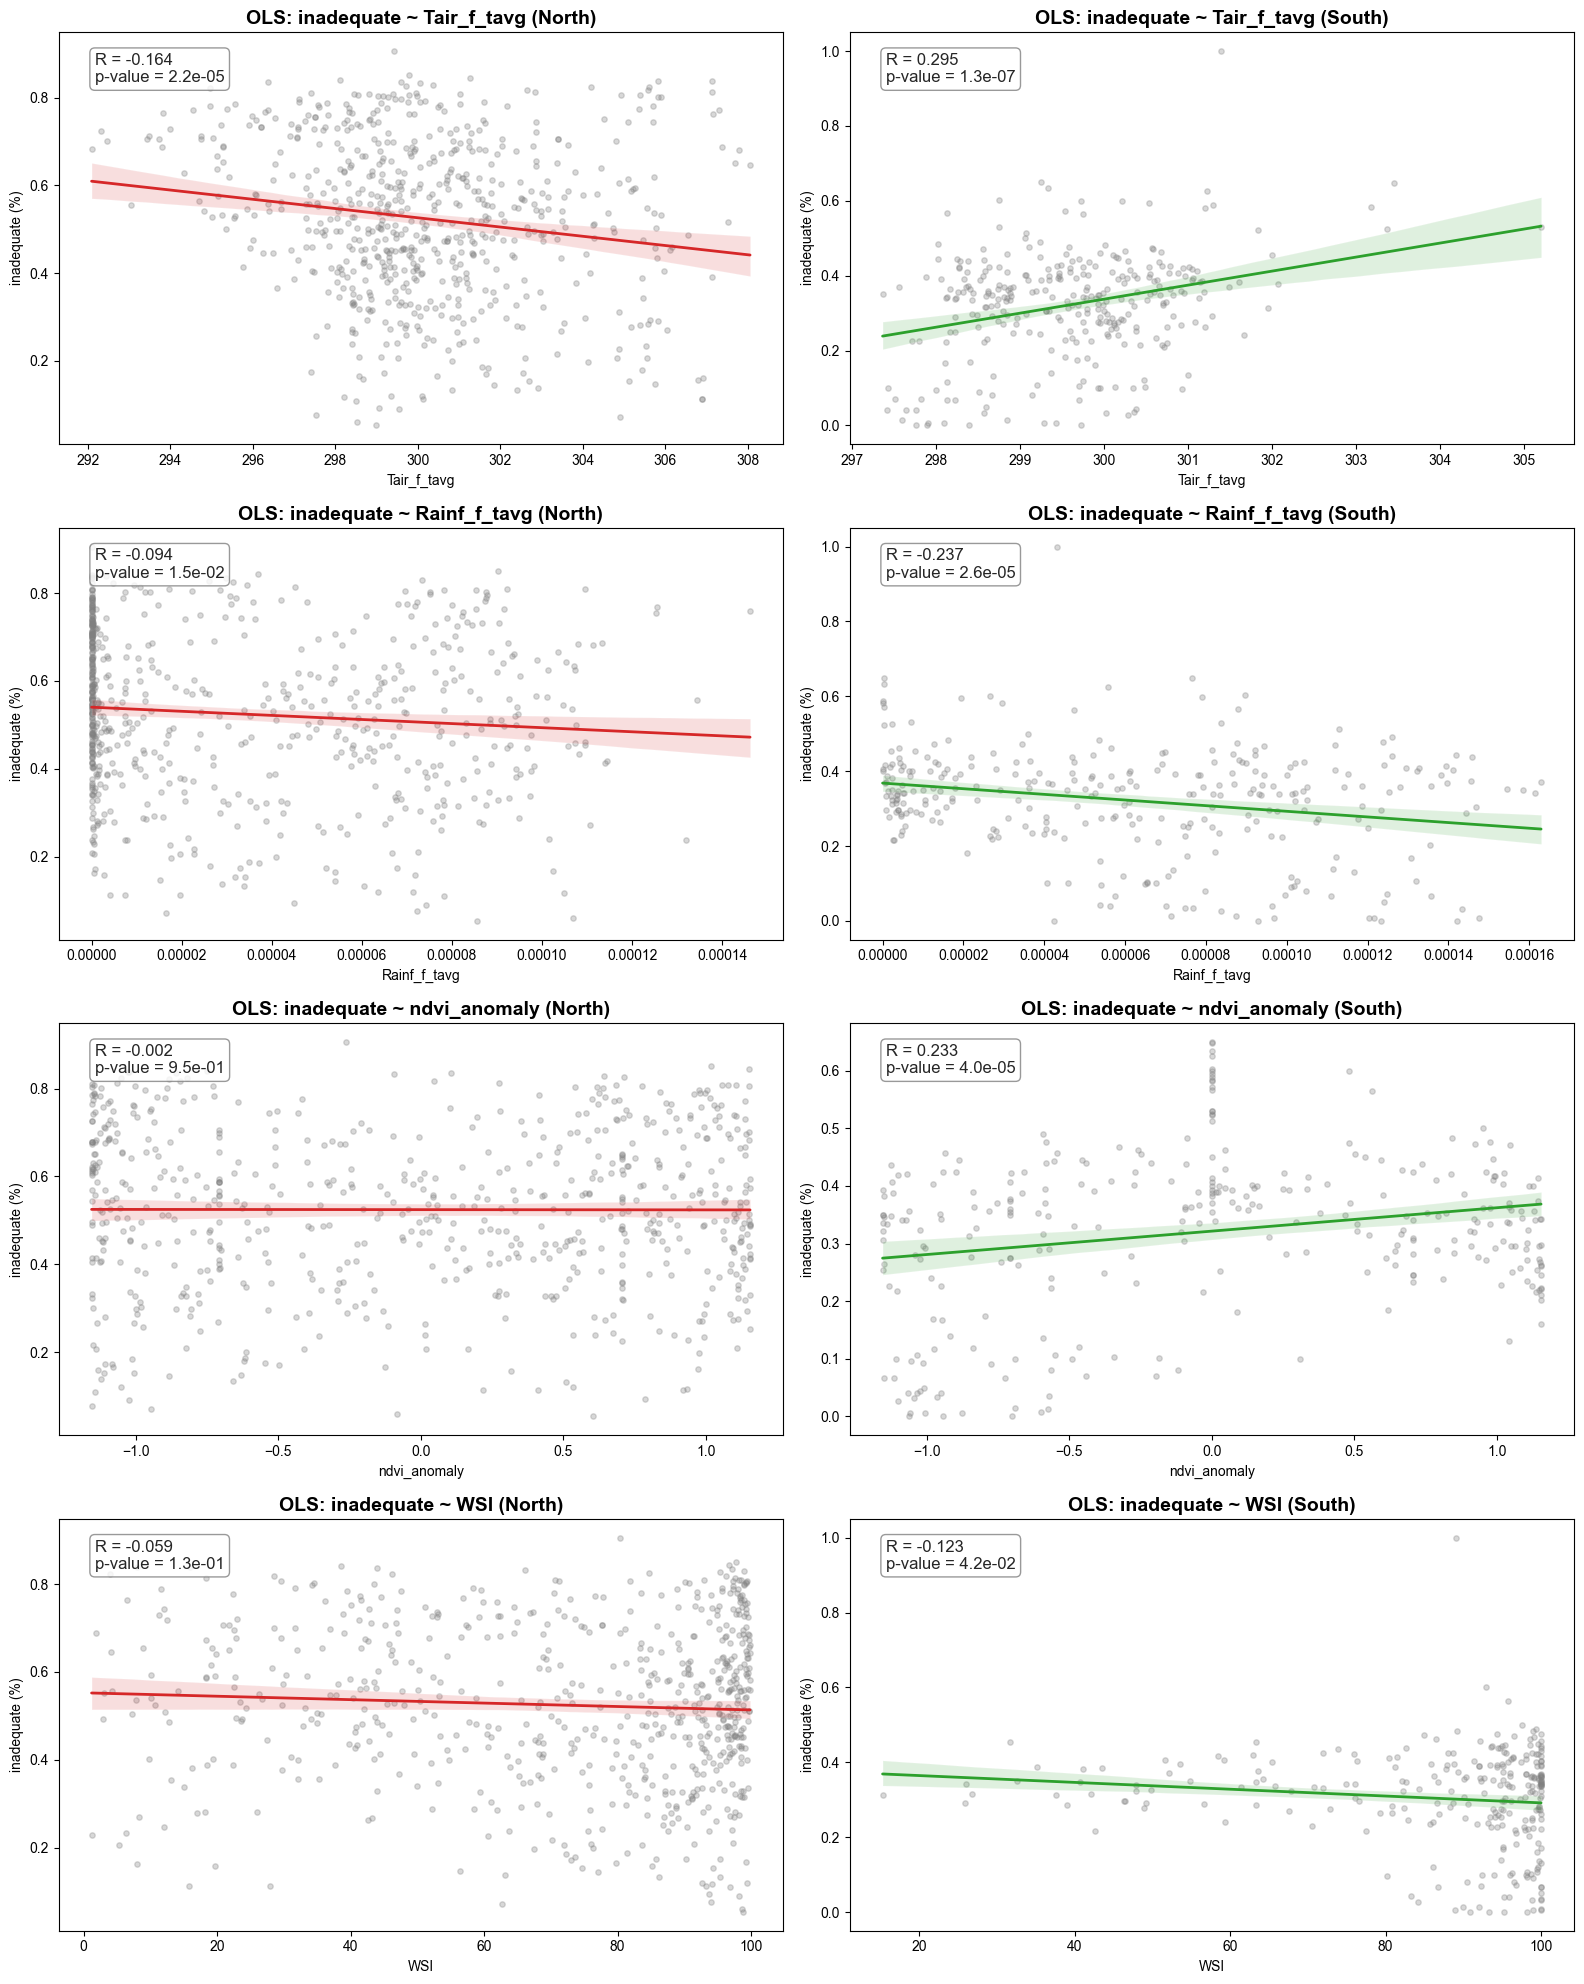

In [1]:
# --- PHASE 4 - STEP 1: Simple Linear Regressions  ---

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

# 1. Chargement des données et définition des régions
filepath = '../data/processed/NIGERIA_WFP_ENGINEERED.csv'
df = pd.read_csv(filepath)

zones = {
    'North': ['Borno', 'Kano', 'Kaduna', 'Katsina', 'Sokoto', 'Kebbi', 'Zamfara', 'Jigawa', 'Yobe', 'Adamawa', 'Bauchi', 'Gombe', 'Taraba', 'Niger', 'Plateau', 'Nasarawa', 'Benue', 'Kogi', 'Kwara', 'Federal Capital Territory', 'Abuja'],
    'South': ['Lagos', 'Ogun', 'Oyo', 'Osun', 'Ekiti', 'Ondo', 'Abia', 'Anambra', 'Ebonyi', 'Enugu', 'Imo', 'Akwa Ibom', 'Bayelsa', 'Cross River', 'Delta', 'Edo', 'Rivers']
}
df['geopolitical_region'] = df['NAME_1'].apply(lambda x: 'North' if x in zones['North'] else 'South')

# 2. Sélection des variables : on intègre la Température, la Pluie, la Végétation et l'Eau
target = 'inadequate'
features_to_regress = ['Tair_f_tavg', 'Rainf_f_tavg', 'ndvi_anomaly', 'WSI'] 

# 3. Préparation de la figure (4 lignes, 2 colonnes)
fig, axes = plt.subplots(len(features_to_regress), 2, figsize=(16, 5 * len(features_to_regress)))
sns.set_theme(style="whitegrid")

for i, feature in enumerate(features_to_regress):
    for j, region in enumerate(['North', 'South']):
        
        # Filtrer et nettoyer
        reg_data = df[df['geopolitical_region'] == region][[feature, target]].dropna()
        ax = axes[i, j]
        
        # Régression OLS
        sns.regplot(
            data=reg_data, 
            x=feature, 
            y=target, 
            ax=ax,
            scatter_kws={'alpha': 0.3, 'color': 'gray', 's': 15}, 
            line_kws={'color': 'tab:red' if region == 'North' else 'tab:green', 'linewidth': 2}
        )
        
        # Stats
        r, p_value = stats.pearsonr(reg_data[feature], reg_data[target])
        
        # Titres et labels
        ax.set_title(f'OLS: {target} ~ {feature} ({region})', fontsize=14, fontweight='bold')
        ax.set_xlabel(f'{feature}')
        ax.set_ylabel(f'{target} (%)')
        
        # Encadré statistique
        textstr = f'R = {r:.3f}\np-value = {p_value:.1e}'
        props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
        ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=12,
                verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()